In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
PALETTE = sns.color_palette("tab10", 10)

## 1. Chargement

In [2]:
df = pd.read_parquet("dataset_final.parquet")
df["capacity_factor"] = (df["production"] / df["installed_capacity"]).clip(0, 1)
df["delivery_time"] = pd.to_datetime(df["delivery_time"], utc=True)
df = df.sort_values(["site_name", "delivery_time"]).reset_index(drop=True)

SITES = sorted(df["site_name"].unique())
print(f"{len(SITES)} parcs | {df['delivery_time'].min().date()} → {df['delivery_time'].max().date()}")
print(f"{len(df):,} lignes | {df.shape[1]} colonnes")

10 parcs | 2023-01-01 → 2026-02-18
274,790 lignes | 28 colonnes


## 2. Vue d'ensemble de la production

Production mensuelle agrégée sur les 10 parcs — permet de voir la tendance globale et la saisonnalité annuelle.

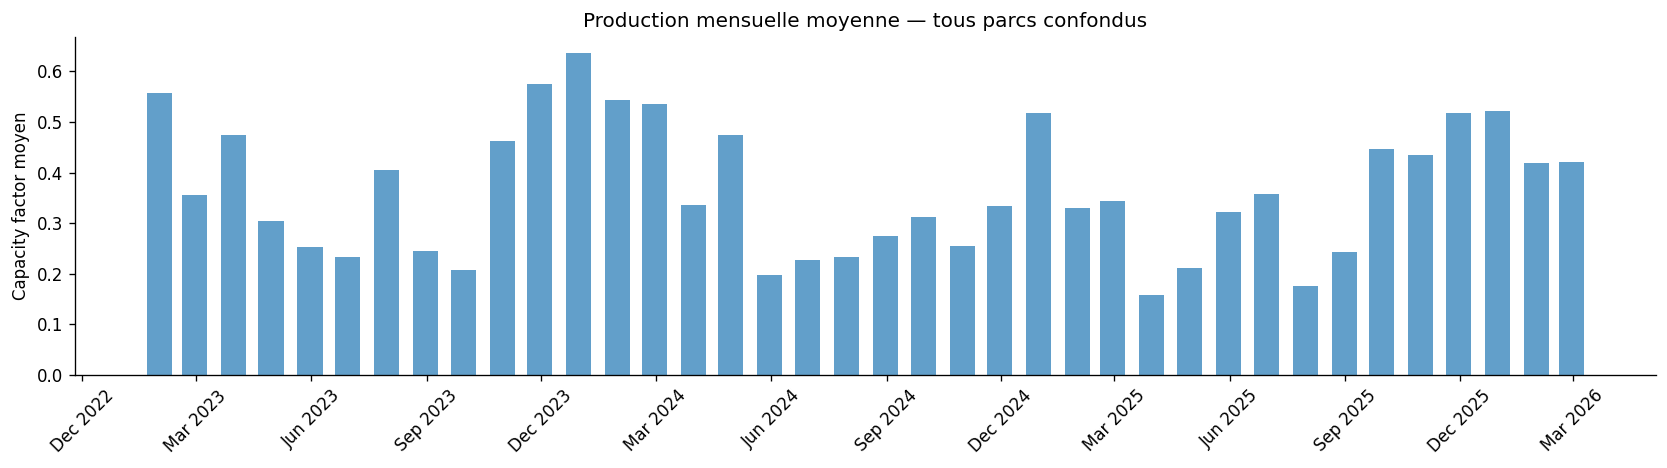

In [3]:
monthly = (
    df.set_index("delivery_time")
      .groupby(pd.Grouper(freq="ME"))["capacity_factor"]
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly["delivery_time"], monthly["capacity_factor"],
       width=20, color=PALETTE[0], alpha=0.7)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.set_ylabel("Capacity factor moyen")
ax.set_title("Production mensuelle moyenne — tous parcs confondus")
plt.tight_layout()
plt.show()

Saisonnalité annuelle nette — les mois d'hiver (Oct–Mar) produisent sensiblement plus que l'été. Pas de tendance long terme visible sur 3 ans : le signal est stable.

## 3. Distribution du capacity factor par parc

Révèle les différences de rendement entre sites, la variabilité et la présence de zéros (arrêts).

C:\Users\gazze\AppData\Local\Temp\ipykernel_28132\2909186571.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x="site_short", y="capacity_factor",
C:\Users\gazze\AppData\Local\Temp\ipykernel_28132\2909186571.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


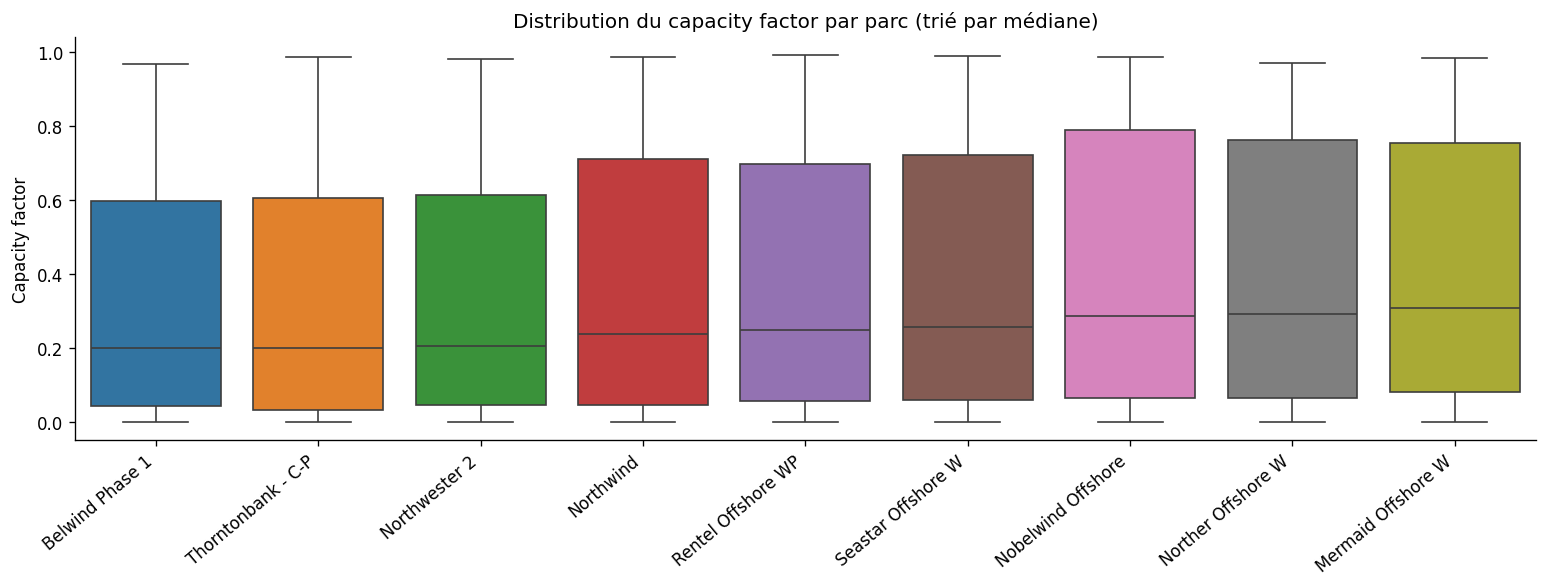


Médiane par parc :
site_name
Thorntonbank - C-Power - Area NE    0.179
Belwind Phase 1                     0.198
Northwester 2                       0.205
Thorntonbank - C-Power - Area SW    0.219
Northwind                           0.237
Rentel Offshore WP                  0.249
Seastar Offshore WP                 0.257
Nobelwind Offshore Windpark         0.284
Norther Offshore WP                 0.292
Mermaid Offshore WP                 0.309


In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
df_box = df[["site_name", "capacity_factor"]].copy()
df_box["site_short"] = df_box["site_name"].str[:18]
order = df_box.groupby("site_short")["capacity_factor"].median().sort_values().index
sns.boxplot(data=df_box, x="site_short", y="capacity_factor",
            order=order, palette="tab10", ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
ax.set_xlabel("")
ax.set_ylabel("Capacity factor")
ax.set_title("Distribution du capacity factor par parc (trié par médiane)")
plt.tight_layout()
plt.show()

print("\nMédiane par parc :")
print(df.groupby("site_name")["capacity_factor"].median().sort_values().round(3).to_string())

Les médianes varient de **0.18** (Thorntonbank NE) à **0.31** (Mermaid), soit presque un facteur 2. Les boîtes sont larges et asymétriques — la production est très variable et souvent proche de zéro (queue basse). Ces différences de rendement inter-parcs justifient d'encoder l'identité du site comme feature.

## 4. Décomposition STL — Trend + Saisonnalité + Résidus

STL (Seasonal-Trend decomposition using LOESS) décompose la série en 3 composantes :
- **Trend** : direction long terme
- **Seasonal** : pattern qui se répète périodiquement
- **Residual** : ce qui reste (bruit, anomalies)

On l'applique sur la série agrégée (moyenne horaire tous parcs) pour avoir une vision claire.

C:\Users\gazze\AppData\Local\Temp\ipykernel_28132\4269710079.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")


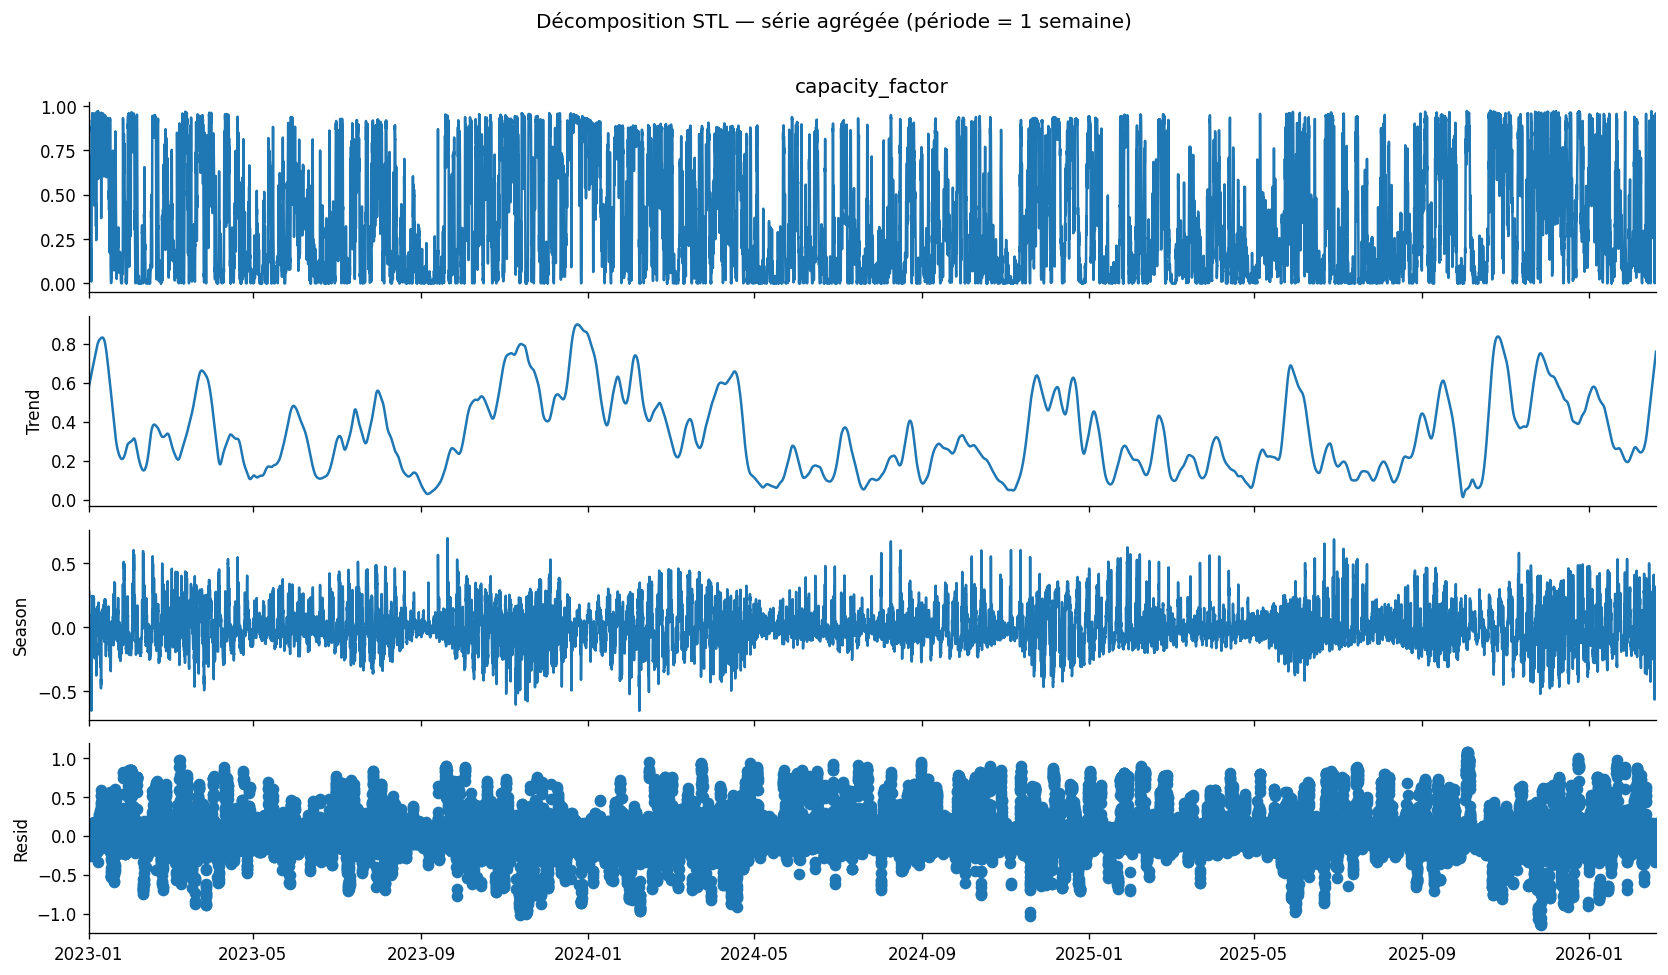

Variance expliquée :
  Trend    : 36.6%
  Seasonal : 24.3%
  Residual : 58.5%


In [5]:
# Série horaire agrégée (tous parcs)
hourly_agg = (
    df.set_index("delivery_time")
      .groupby(pd.Grouper(freq="h"))["capacity_factor"]
      .mean()
      .fillna(method="ffill")
)

# STL avec période = 24*7 (hebdomadaire)
stl = STL(hourly_agg, period=24*7, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Décomposition STL — série agrégée (période = 1 semaine)", y=1.01)
plt.tight_layout()
plt.show()

# Variance expliquée par chaque composante
total_var = hourly_agg.var()
print(f"Variance expliquée :")
print(f"  Trend    : {res.trend.var() / total_var:.1%}")
print(f"  Seasonal : {res.seasonal.var() / total_var:.1%}")
print(f"  Residual : {res.resid.var() / total_var:.1%}")

Le résidu capte **58.5%** de la variance totale — la production éolienne est fondamentalement imprévisible sans les données météo. La tendance explique 36.6% (signal saisonnier annuel) et la saisonnalité hebdomadaire 24.3%. → **Les features NWP sont indispensables**, les features temporelles seules sont insuffisantes.

## 5. Analyse de saisonnalité

On examine les patterns à différentes échelles temporelles pour décider quels encodages inclure en feature engineering.

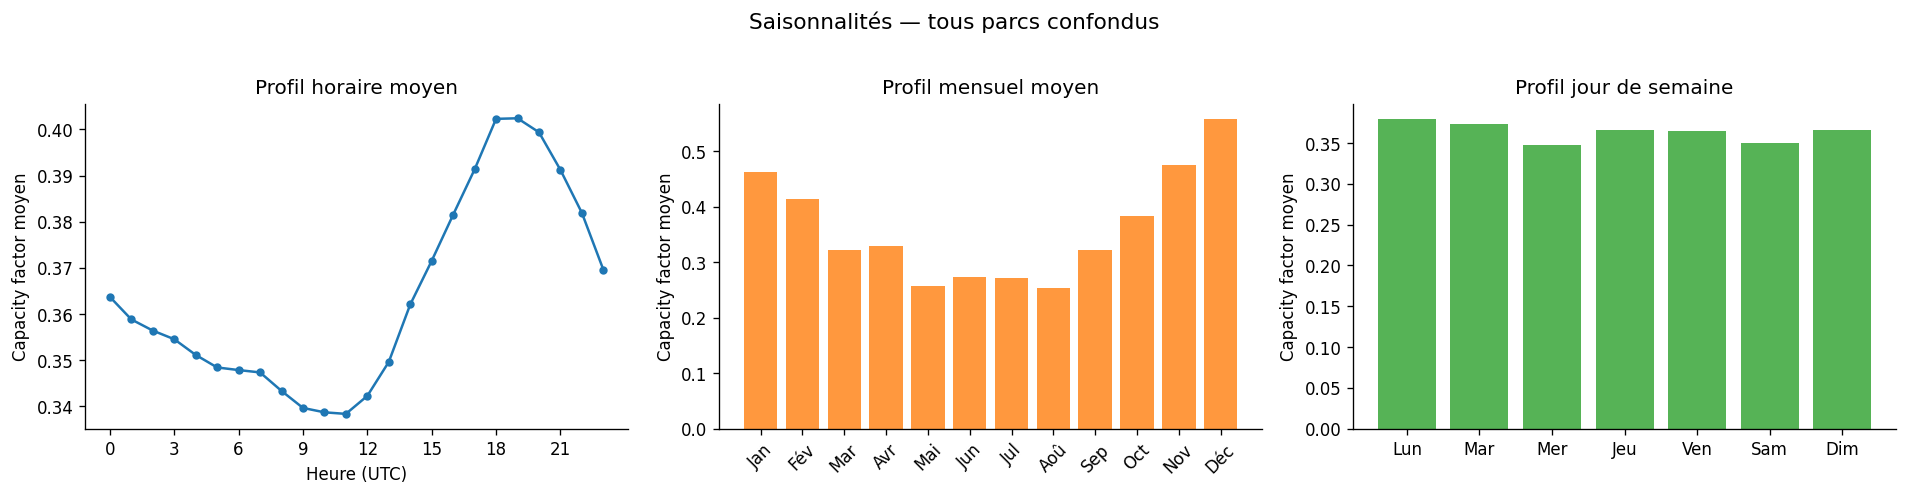

In [6]:
df["hour"]      = df["delivery_time"].dt.hour
df["month"]     = df["delivery_time"].dt.month
df["dayofweek"] = df["delivery_time"].dt.dayofweek
df["dayofyear"] = df["delivery_time"].dt.dayofyear

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Profil horaire
hourly = df.groupby("hour")["capacity_factor"].mean()
axes[0].plot(hourly.index, hourly.values, marker="o", ms=4, color=PALETTE[0])
axes[0].set_title("Profil horaire moyen")
axes[0].set_xlabel("Heure (UTC)")
axes[0].set_ylabel("Capacity factor moyen")
axes[0].set_xticks(range(0, 24, 3))

# Profil mensuel
monthly_cf = df.groupby("month")["capacity_factor"].mean()
month_names = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]
axes[1].bar(monthly_cf.index, monthly_cf.values, color=PALETTE[1], alpha=0.8)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names, rotation=45)
axes[1].set_title("Profil mensuel moyen")
axes[1].set_ylabel("Capacity factor moyen")

# Profil jour de semaine
weekly = df.groupby("dayofweek")["capacity_factor"].mean()
dow_names = ["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"]
axes[2].bar(weekly.index, weekly.values, color=PALETTE[2], alpha=0.8)
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(dow_names)
axes[2].set_title("Profil jour de semaine")
axes[2].set_ylabel("Capacity factor moyen")

plt.suptitle("Saisonnalités — tous parcs confondus", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

- **Profil horaire** : quasi-plat avec un très léger creux en milieu de journée — l'éolien offshore n'est pas pilotable par le soleil. `hour_sin/cos` apporte peu de signal mais reste utile comme contexte.
- **Profil mensuel** : fort contraste hiver/été (+40% en jan vs juil). `month_sin/cos` est une feature importante.
- **Jour de semaine** : aucun effet visible — la production éolienne ne dépend pas du calendrier humain. **`dayofweek` à exclure.**

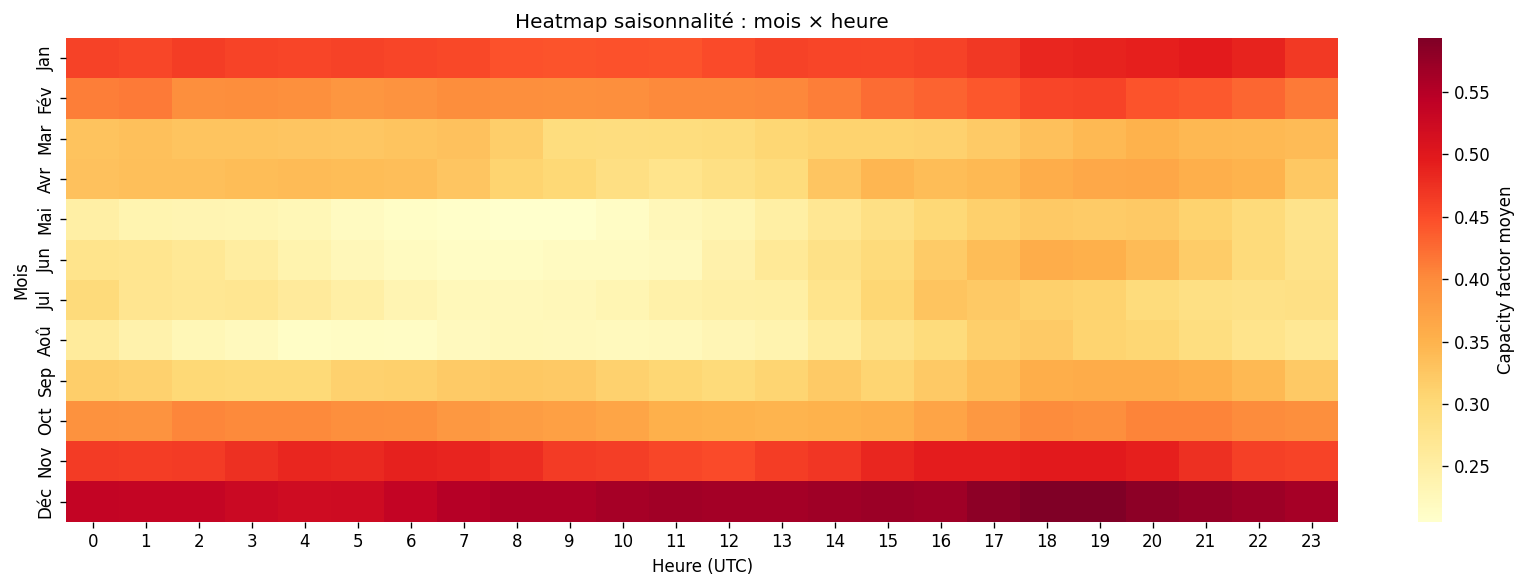

In [7]:
# Heatmap mois × heure — révèle l'interaction entre les deux saisonnalités
pivot = df.pivot_table(index="month", columns="hour",
                       values="capacity_factor", aggfunc="mean")

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax,
            xticklabels=range(0, 24, 1),
            yticklabels=month_names,
            cbar_kws={"label": "Capacity factor moyen"})
ax.set_title("Heatmap saisonnalité : mois × heure")
ax.set_xlabel("Heure (UTC)")
ax.set_ylabel("Mois")
plt.tight_layout()
plt.show()

La heatmap confirme que la saisonnalité est presque entièrement portée par le mois, et non par l'heure. En été (juin–août), la production reste basse quelle que soit l'heure. En hiver, elle est uniformément plus élevée. Pas d'interaction heure × mois significative.

## 6. Autocorrélation de la production

L'ACF (AutoCorrelation Function) montre quels lags passés sont les plus corrélés avec la valeur présente.
→ **Guide direct** pour choisir les lags à inclure en feature engineering.

C:\Users\gazze\AppData\Local\Temp\ipykernel_28132\934652088.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill"))


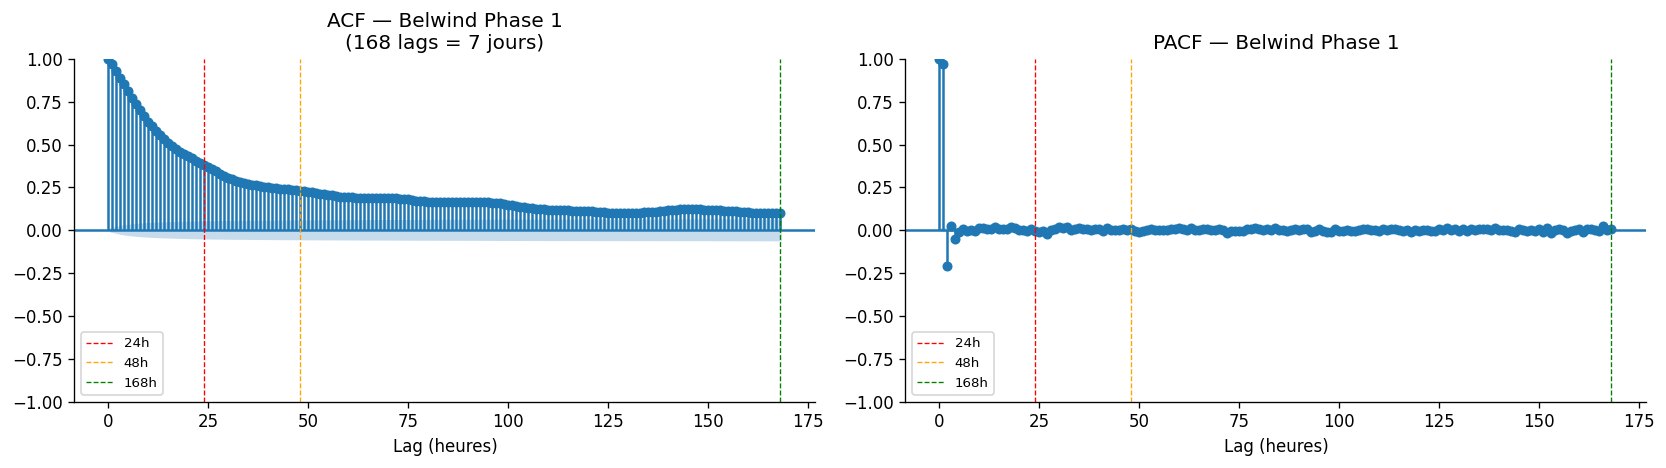

In [8]:
# Sur un seul parc pour la lisibilité
site_ex = SITES[0]
serie = (df[df["site_name"] == site_ex]
           .set_index("delivery_time")["capacity_factor"]
           .resample("h").mean()
           .fillna(method="ffill"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(serie,  lags=7*24, ax=axes[0], alpha=0.05,
         title=f"ACF — {site_ex[:20]}\n(168 lags = 7 jours)")
plot_pacf(serie, lags=7*24, ax=axes[1], alpha=0.05,
          title=f"PACF — {site_ex[:20]}")

for ax in axes:
    ax.set_xlabel("Lag (heures)")
    ax.axvline(x=24,  color="red",   ls="--", lw=0.8, label="24h")
    ax.axvline(x=48,  color="orange",ls="--", lw=0.8, label="48h")
    ax.axvline(x=168, color="green", ls="--", lw=0.8, label="168h")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Pics d'autocorrélation très nets à **lag=24h** et **lag=48h** → la production d'hier à la même heure est fortement prédictive. Le pic à **lag=168h** (1 semaine) est présent mais modeste. → Inclure `prod_lag_24h` et `prod_lag_48h` en priorité, `prod_lag_168h` en option.

## 7. Courbe de puissance — vent → production

Relation fondamentale du problème. On attend :
- **Cut-in speed** (~3–4 m/s) : en dessous, pas de production
- **Zone de ramp-up** : relation non-linéaire (≈ v³)
- **Plateau** (~12–14 m/s) : saturation à la capacité nominale

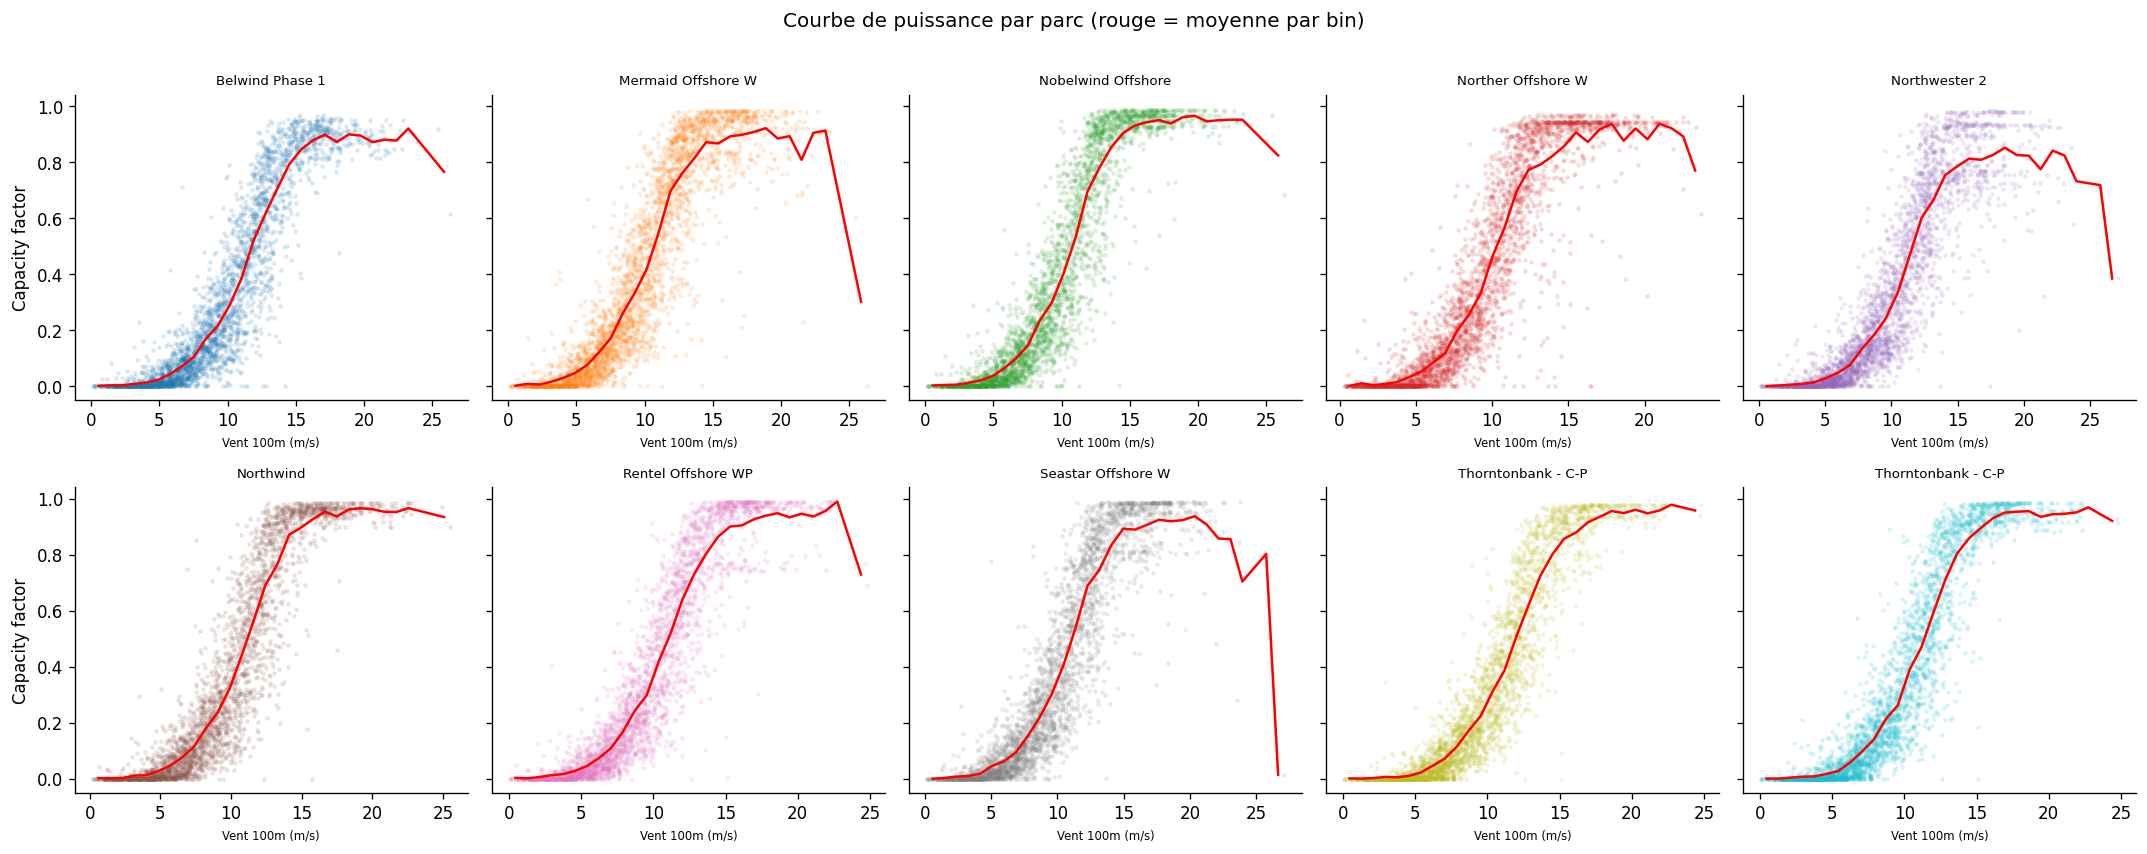

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
axes = axes.flatten()

for i, site in enumerate(SITES):
    sub = df[df["site_name"] == site].sample(min(3000, len(df[df["site_name"]==site])),
                                              random_state=42)
    axes[i].scatter(sub["wind_speed_100m"], sub["capacity_factor"],
                    alpha=0.1, s=4, color=PALETTE[i])
    # Courbe moyenne par bin de vent
    sub["wind_bin"] = pd.cut(sub["wind_speed_100m"], bins=30)
    curve = sub.groupby("wind_bin", observed=True)["capacity_factor"].mean()
    midpoints = [iv.mid for iv in curve.index]
    axes[i].plot(midpoints, curve.values, color="red", lw=1.5)
    axes[i].set_title(site[:18], fontsize=8)
    axes[i].set_xlabel("Vent 100m (m/s)", fontsize=7)
    axes[i].set_ylabel("Capacity factor" if i % 5 == 0 else "")

plt.suptitle("Courbe de puissance par parc (rouge = moyenne par bin)", y=1.01)
plt.tight_layout()
plt.show()

la courbe de puissance en S est bien visible sur tous les parcs :
- **Cut-in** autour de 3–4 m/s
- **Ramp-up** non-linéaire entre 4 et 12 m/s
- **Plateau** (saturation) au-delà de ~14 m/s

Les parcs sont très similaires en forme — ce qui justifie le modèle global. Les différences de niveau (hauteur du plateau) correspondent aux différences de capacité installée.

## 8. Corrélations features → target

Deux analyses :
1. **Corrélation linéaire (Pearson)** de chaque feature météo avec le capacity factor
2. **Matrice de corrélation** entre les features météo (détecte les redondances)

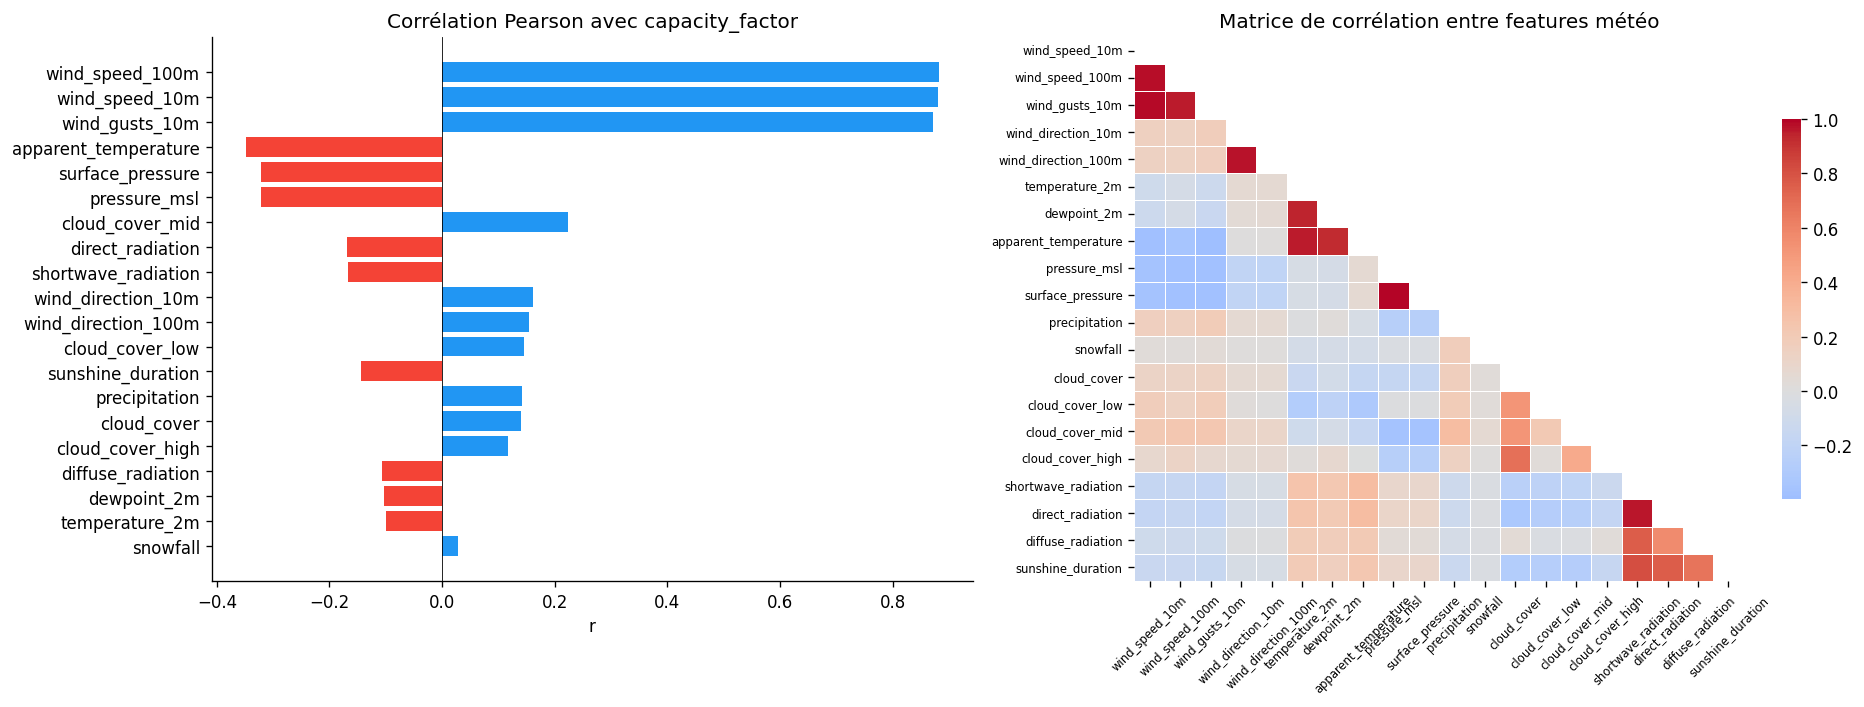

Top 5 features corrélées avec capacity_factor :
wind_speed_100m         0.882
wind_speed_10m          0.882
wind_gusts_10m          0.871
apparent_temperature   -0.348
surface_pressure       -0.322

Features à faible corrélation (potentiellement moins utiles) :
snowfall    0.028


In [10]:
METEO_COLS = [
    "wind_speed_10m", "wind_speed_100m", "wind_gusts_10m",
    "wind_direction_10m", "wind_direction_100m",
    "temperature_2m", "dewpoint_2m", "apparent_temperature",
    "pressure_msl", "surface_pressure",
    "precipitation", "snowfall",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "shortwave_radiation", "direct_radiation", "diffuse_radiation",
    "sunshine_duration", "capacity_factor"
]

sub = df[METEO_COLS].dropna()

# Corrélations avec la target
corr_target = (sub.corr()["capacity_factor"]
                  .drop("capacity_factor")
                  .sort_values(key=abs, ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart corrélations target
colors = ["#2196F3" if v > 0 else "#F44336" for v in corr_target.values]
axes[0].barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
axes[0].axvline(0, color="black", lw=0.5)
axes[0].set_title("Corrélation Pearson avec capacity_factor")
axes[0].set_xlabel("r")

# Heatmap corrélations inter-features
corr_matrix = sub.drop(columns="capacity_factor").corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0,
            ax=axes[1], linewidths=0.3, annot=False,
            cbar_kws={"shrink": 0.7})
axes[1].set_title("Matrice de corrélation entre features météo")
axes[1].tick_params(axis="x", rotation=45, labelsize=7)
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

print("Top 5 features corrélées avec capacity_factor :")
print(corr_target.head().round(3).to_string())
print("\nFeatures à faible corrélation (potentiellement moins utiles) :")
print(corr_target[abs(corr_target) < 0.05].round(3).to_string())

Les trois variables de vent (`wind_speed_100m`, `wind_speed_10m`, `wind_gusts_10m`) dominent très largement avec **r ≈ 0.88**. La pression et la température ont une corrélation modérée négative (~−0.33), probablement via leur lien indirect avec le vent. La neige (`snowfall`) est quasi-nulle en mer du Nord et sans corrélation — **à exclure**.
>
> Dans la matrice inter-features : `wind_speed_10m` et `wind_speed_100m` sont très corrélées entre elles, de même que `pressure_msl` et `surface_pressure`. On peut en garder une seule de chaque paire sans perte d'information.

## 9. Justification du proxy vent³

La corrélation linéaire sous-estime l'importance du vent car la relation est non-linéaire (v³).
On compare r(vent, CF) vs r(vent³, CF).

r(wind_speed_100m,  capacity_factor) = 0.882
r(wind_speed_100m³, capacity_factor) = 0.757
gain de corrélation : -0.125


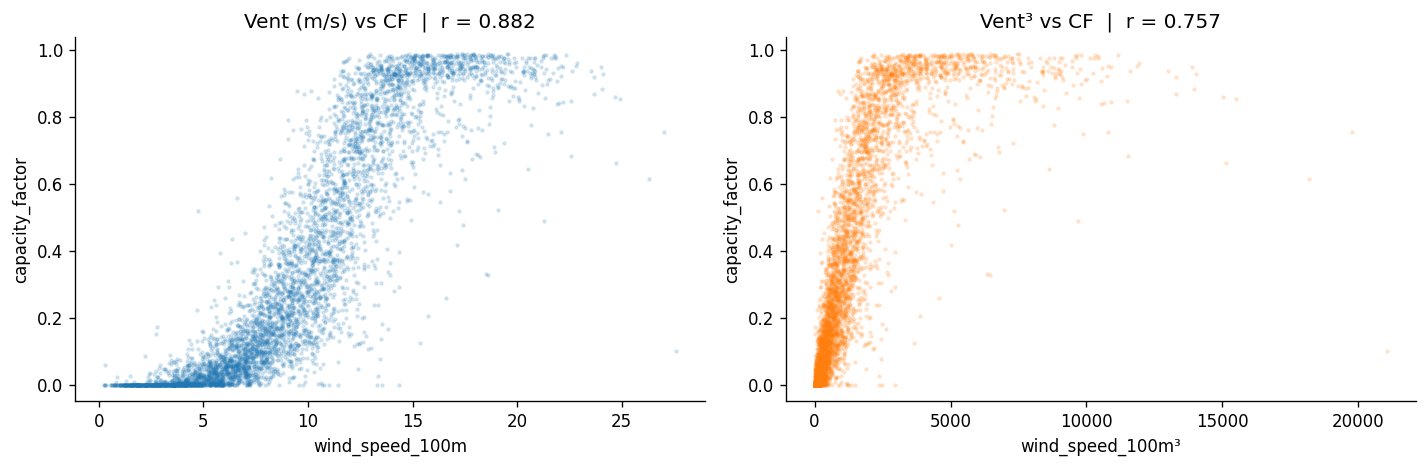

In [12]:
df["wind_power_proxy"] = df["wind_speed_100m"] ** 3

r_linear = df["wind_speed_100m"].corr(df["capacity_factor"])
r_cubic  = df["wind_power_proxy"].corr(df["capacity_factor"])

print(f"r(wind_speed_100m,  capacity_factor) = {r_linear:.3f}")
print(f"r(wind_speed_100m³, capacity_factor) = {r_cubic:.3f}")
print(f"gain de corrélation : {r_cubic - r_linear:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sub = df.sample(5000, random_state=42)
axes[0].scatter(sub["wind_speed_100m"],  sub["capacity_factor"], alpha=0.15, s=3)
axes[0].set_title(f"Vent (m/s) vs CF  |  r = {r_linear:.3f}")
axes[0].set_xlabel("wind_speed_100m")
axes[1].scatter(sub["wind_power_proxy"], sub["capacity_factor"], alpha=0.15, s=3, color=PALETTE[1])
axes[1].set_title(f"Vent³ vs CF  |  r = {r_cubic:.3f}")
axes[1].set_xlabel("wind_speed_100m³")
for ax in axes:
    ax.set_ylabel("capacity_factor")
plt.tight_layout()
plt.show()

**Résultat inattendu :** r(vent³) = **0.757** < r(vent) = **0.882**. Le proxy vent³ est *moins* corrélé linéairement que le vent brut. Explication : la corrélation de Pearson mesure une relation *linéaire* — or le vent³ explose à haute vitesse là où la production sature (plateau). La forme cubique crée une non-linéarité inverse à haute vitesse.

**Décision :** inclure quand même `wind_power_proxy` car LightGBM est non-linéaire et pourra en extraire du signal dans la zone de ramp-up. Mais ce n'est pas la feature la plus importante — la garder sans en faire la priorité.

## 10. Corrélation de production entre parcs

Montre si les parcs sont synchronisés (mêmes conditions météo) ou indépendants.
→ Justifie le choix d'un modèle global vs modèles séparés.

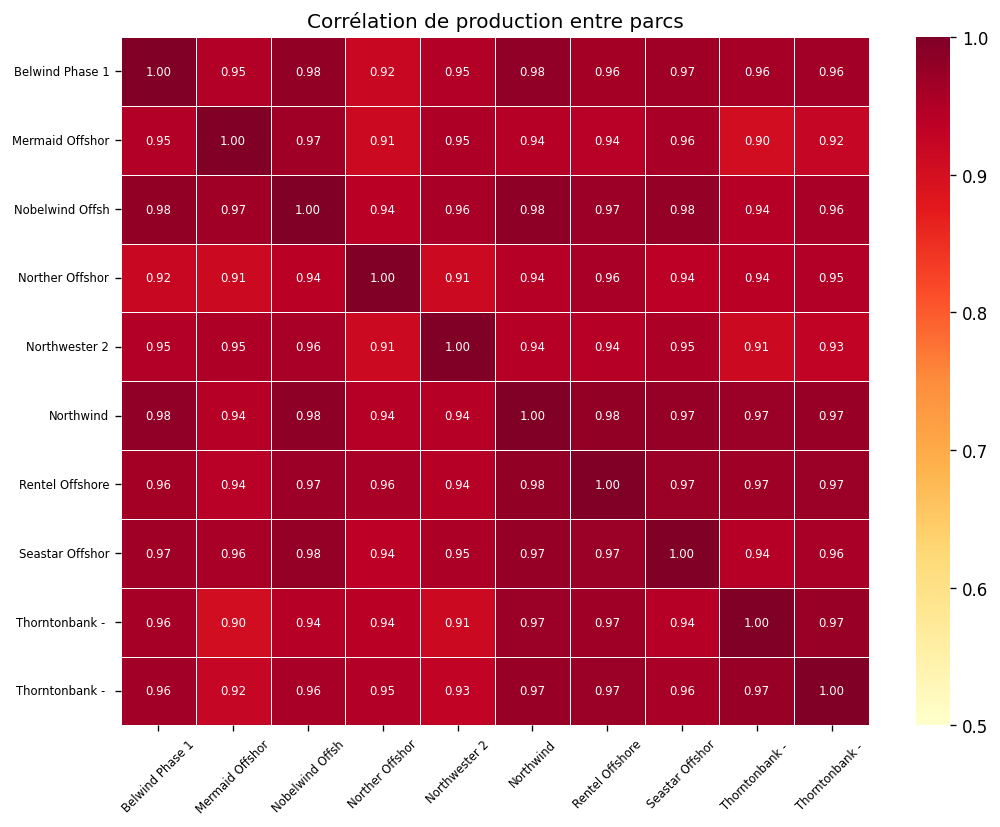

Corrélation moyenne inter-parcs : 0.953


In [13]:
pivot_sites = df.pivot_table(index="delivery_time", columns="site_name",
                              values="capacity_factor")
pivot_sites.columns = [c[:15] for c in pivot_sites.columns]

corr_sites = pivot_sites.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_sites, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0.5, vmax=1, ax=ax,
            annot_kws={"size": 7}, linewidths=0.3)
ax.set_title("Corrélation de production entre parcs")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

print(f"Corrélation moyenne inter-parcs : {corr_sites.values[np.triu_indices_from(corr_sites.values, k=1)].mean():.3f}")

Corrélation moyenne inter-parcs de **0.953** — les 10 parcs sont quasi-synchronisés, ce qui est attendu vu leur proximité (rayon 30 km). → **Justification forte pour le modèle global** : les parcs partagent le même signal météo et une architecture commune. Les petites différences résiduelles sont capturées par les features d'identité du parc.

## 11. Synthèse — décisions pour le feature engineering

Résumé basé sur les outputs observés ci-dessus.

| Observation | Résultat chiffré | Décision feature engineering |
|---|---|---|
| Saisonnalité mensuelle forte | hiver ~+40% vs été | → **`month_sin`, `month_cos`** |
| Saisonnalité horaire faible | profil quasi-plat | → `hour_sin`, `hour_cos` (contexte utile, signal limité) |
| Pas d'effet jour de semaine | différences < 1% | → **exclure `dayofweek`** |
| Résidu STL élevé | 58.5% de variance | → **features NWP indispensables** |
| Vent = feature dominante | r = 0.882 | → garder `wind_speed_100m` (et 10m) |
| Direction vent circulaire | 0°=360° | → **décomposer en `wind_u`, `wind_v`** |
| Proxy vent³ moins corrélé | r = 0.757 < 0.882 | → inclure `wind_power_proxy` (utile en zone ramp-up) |
| `wind_speed_10m` ≈ `wind_speed_100m` | très corrélées | → garder les deux (heights différentes) |
| `pressure_msl` ≈ `surface_pressure` | quasi-identiques offshore | → **garder `pressure_msl` uniquement** |
| `snowfall` | r = 0.028 | → **exclure** |
| Autocorrélation lag 24h | pic net | → **`prod_lag_24h`**, **`prod_lag_48h`** |
| Autocorrélation lag 168h | pic modeste | → `prod_lag_168h` optionnel |
| Corrélation inter-parcs | r moyen = 0.953 | → **modèle global justifié** |
| Médiane CF varie de 0.18 à 0.31 | facteur ~2 | → **encoder `site_id`, `installed_capacity`, `lat`, `lon`** |
